In [ ]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

path = r"Your path to the csv file"
df = pd.read_csv(path)

In [2]:
df = df[df['Profession'] == 'Student']
df = df.drop(columns=['Profession', 'Work Pressure', 'Job Satisfaction'])
df = df.dropna(subset=['Financial Stress'])
city_counts = df['City'].value_counts()
cities_to_group = city_counts[city_counts < 100].index
df['City'] = df['City'].replace(cities_to_group, 'Other')

<Axes: xlabel='Gender', ylabel='Depression'>

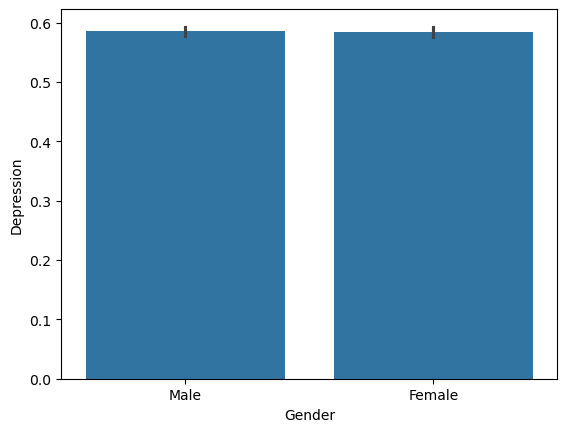

In [6]:
sns.barplot(data=df, x='Gender', y='Depression')

<Axes: xlabel='Gender', ylabel='count'>

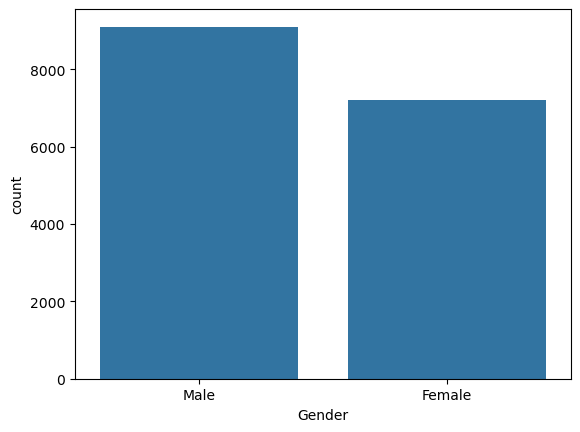

In [8]:
depressed_students = df[df['Depression'] == 1]
sns.countplot(data=depressed_students, x='Gender')

Even though there are a lot more depressed males, their propotions are almost the same.
This might looks as if we should drop the gender column, we wanted to run chi-squared to make sure.

In [ ]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(df['Gender'], df['Depression'])
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"p-value: {p_value}")

Chi-Square Statistic: 0.1004
p-value: 0.7513915658890091


Since p-value > 0.05, we failed to reject H0 meaning Gender is not statisticly significant.
This means we will be dropping gender column.

In [10]:
df = df.drop(columns=['Gender'])

In [12]:
df.head()

,id,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,33.0,Visakhapatnam,5.0,8.97,2.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,24.0,Bangalore,2.0,5.90,5.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,31.0,Srinagar,3.0,7.03,5.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,28.0,Varanasi,3.0,5.59,2.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,25.0,Jaipur,4.0,8.13,3.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
